# Notebook 2 — Data Exploration

Understand the data before modelling. Goal of this notebook:

1. Sanity-check LTA speed-band coverage across Singapore.
2. Inspect the OSM road network (connectedness, edge lengths, road-class mix).
3. Match LTA speed bands to OSM edges and measure the match rate.
4. Save `data/processed/edges_with_traffic.parquet` — the input that
   Notebook 3 uses to compute ground-truth travel times.

Run after Notebook 1 has populated `data/processed/`.

In [1]:
# Auto-reload edits to src/ without restarting the kernel.
%load_ext autoreload
%autoreload 2

## 1. Setup + load processed data

In [2]:
from __future__ import annotations

import logging
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s %(name)s: %(message)s')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import osmnx as ox
import networkx as nx

from src.config import PROCESSED_DIR, DEMO_STATIONS
from src.network import (
    load_road_network, match_speedbands_to_edges, edges_with_traffic,
    road_class_ordinal,
)
from src.viz import base_map, add_stations

sns.set_style('whitegrid')

speedbands = pd.read_parquet(PROCESSED_DIR / 'speedbands.parquet')
print(f'Loaded {len(speedbands):,} LTA speed bands')
display(speedbands.head())

G = load_road_network()
print(f'Loaded OSM network: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges')

Loaded 56,785 LTA speed bands


,LinkID,RoadName,RoadCategory,SpeedBand,MinimumSpeed,MaximumSpeed,StartLng,StartLat,EndLng,EndLat
0,103011995,NARAYANAN CHETTY ROAD,E,2,10,19,103.83838061586873,1.2921590838224843,103.83817446261223,1.2917846048262231
1,103076902,RIVER VALLEY ROAD,B,5,40,49,103.84010402084176,1.295904895647087,103.83881860907599,1.295778586140851
2,103085351,BARTLEY ROAD,B,7,60,69,103.88146411588032,1.3420255972905863,103.88186075458927,1.3418453134509019
3,103007935,MUTHURAMAN CHETTY ROAD,E,3,20,29,103.83762351307742,1.2921118050279892,103.83797275045582,1.2926461393409348
4,103012043,MARTIN ROAD,E,4,30,39,103.83817446261223,1.2917846048262231,103.83840296152836,1.2916111381542603


Loaded OSM network: 24,214 nodes, 46,082 edges


## 2. LTA speed-band distribution

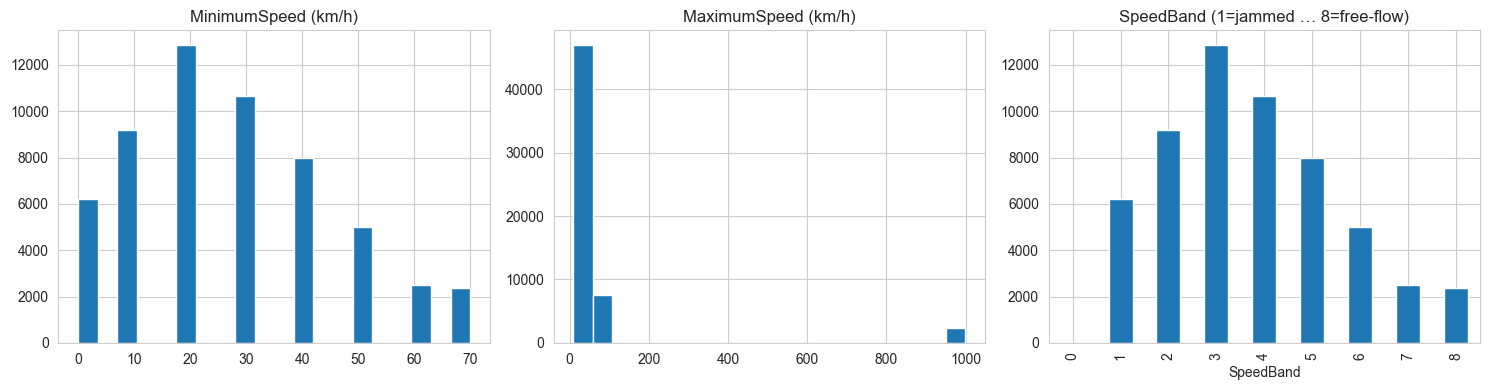


Road-name top 10 (by row count):
RoadName
PAN ISLAND EXPRESSWAY    903
AYER RAJAH EXPRESSWAY    474
CENTRAL EXPRESSWAY       415
TAMPINES EXPRESSWAY      376
YIO CHU KANG ROAD        346
EAST COAST PARKWAY       303
SELETAR EXPRESSWAY       268
SEMBAWANG ROAD           249
UPPER SERANGOON ROAD     248
WEST COAST HIGHWAY       237
Name: count, dtype: int64


In [3]:
# Coerce numeric in case the parquet round-trip left strings.
for col in ['MinimumSpeed', 'MaximumSpeed', 'SpeedBand']:
    if col in speedbands.columns:
        speedbands[col] = pd.to_numeric(speedbands[col], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
speedbands['MinimumSpeed'].dropna().hist(bins=20, ax=axes[0])
axes[0].set_title('MinimumSpeed (km/h)')
speedbands['MaximumSpeed'].dropna().hist(bins=20, ax=axes[1])
axes[1].set_title('MaximumSpeed (km/h)')
speedbands['SpeedBand'].dropna().astype(int).value_counts().sort_index().plot.bar(ax=axes[2])
axes[2].set_title('SpeedBand (1=jammed … 8=free-flow)')
plt.tight_layout(); plt.show()

print('\nRoad-name top 10 (by row count):')
print(speedbands['RoadName'].value_counts().head(10))

In [4]:
# Map: plot a sample of speed bands colored by SpeedBand.
# Full set (~50k rows) is too dense; sample 3000 for an interactive folium map.
sample = speedbands.dropna(subset=['StartLat', 'StartLng']).sample(
    min(3000, len(speedbands)), random_state=0,
)

BAND_COLORS = {
    1: '#a50026', 2: '#d73027', 3: '#f46d43', 4: '#fdae61',
    5: '#fee08b', 6: '#d9ef8b', 7: '#a6d96a', 8: '#1a9850',
}

m = base_map(zoom=11)
add_stations(m)
for _, r in sample.iterrows():
    band = int(r['SpeedBand']) if pd.notna(r['SpeedBand']) else 0
    folium.CircleMarker(
        location=(float(r['StartLat']), float(r['StartLng'])),
        radius=2,
        color=BAND_COLORS.get(band, '#888'),
        fill=True, fill_opacity=0.7, weight=0,
    ).add_to(m)
m

## 3. Road network statistics

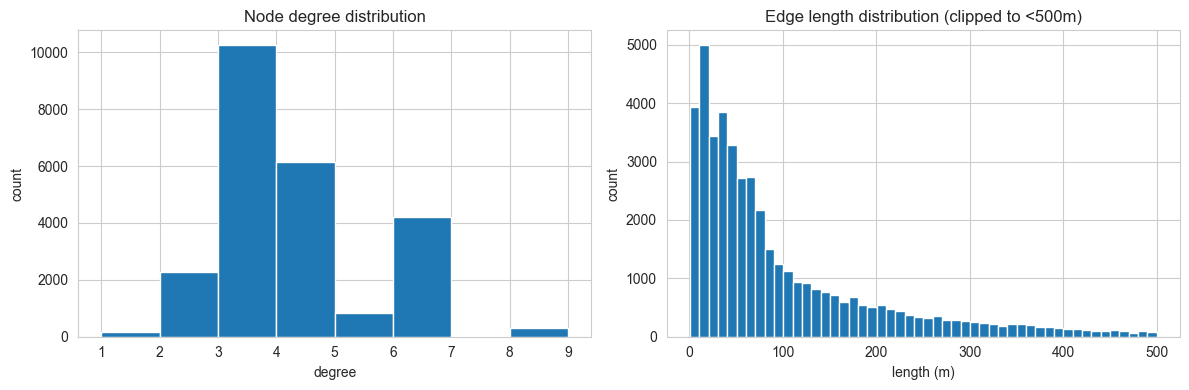

Weakly connected components: 1
Largest WCC: 24,214 nodes (100.0% of graph)

Edge counts by OSM highway tag:
  residential            22,710
  primary                 6,175
  tertiary                4,542
  secondary               4,477
  unclassified            2,146
  primary_link            1,574
  trunk                   1,251
  motorway_link           1,088
  secondary_link            721
  trunk_link                479
  tertiary_link             454
  motorway                  436
  living_street              29


In [5]:
degrees = [d for _, d in G.degree()]
lengths = [data.get('length', 0) for _, _, data in G.edges(data=True)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(degrees, bins=range(1, max(degrees)+2))
axes[0].set_title('Node degree distribution')
axes[0].set_xlabel('degree'); axes[0].set_ylabel('count')

axes[1].hist([l for l in lengths if l < 500], bins=50)
axes[1].set_title('Edge length distribution (clipped to <500m)')
axes[1].set_xlabel('length (m)'); axes[1].set_ylabel('count')
plt.tight_layout(); plt.show()

# Connectedness — for a MultiDiGraph use weakly connected components.
wcc = list(nx.weakly_connected_components(G))
wcc.sort(key=len, reverse=True)
print(f'Weakly connected components: {len(wcc)}')
print(f'Largest WCC: {len(wcc[0]):,} nodes ({len(wcc[0])/G.number_of_nodes():.1%} of graph)')

# Road-class breakdown.
from collections import Counter
hw = Counter()
for _, _, data in G.edges(data=True):
    h = data.get('highway', 'unknown')
    if isinstance(h, list):
        h = h[0]
    hw[str(h)] += 1
print('\nEdge counts by OSM highway tag:')
for tag, n in hw.most_common(15):
    print(f'  {tag:20s} {n:>8,}')

## 4. Match LTA speed bands → OSM edges

For each speed band, find the nearest OSM edge using `osmnx.distance.nearest_edges`
on the band's midpoint. Drop matches farther than 50m (heuristic).

**This cell is the slow one in this notebook** — ~30-60s for the full speed-band set.

In [6]:
matches = match_speedbands_to_edges(G, speedbands, max_distance_m=50.0)
match_rate = matches['matched'].mean() if not matches.empty else 0.0
print(f'Speed bands attempted:  {len(matches):,}')
print(f'Matched within 50m:     {matches["matched"].sum():,} ({match_rate:.1%})')
print(f'Median match distance:  {matches["distance_m"].median():.1f} m')
display(matches.head())

Speed bands attempted:  56,785
Matched within 50m:     30,153 (53.1%)
Median match distance:  42.4 m


,LinkID,SpeedBand,u,v,key,distance_m,matched
0,103011995,2,4598515829,4598515816,0,25.491278,True
1,103076902,5,4594223602,4594223598,0,20.608683,True
2,103085351,7,378627241,239824768,0,215.043093,False
3,103007935,3,4598515837,6378015250,0,75.796738,False
4,103012043,4,1790339971,370965237,0,30.176717,True


In [7]:
# Map matched vs unmatched (sample to keep folium fast).
merged = speedbands.reset_index(drop=True).merge(
    matches[['LinkID', 'matched', 'distance_m']], on='LinkID', how='left',
)
sample = merged.dropna(subset=['StartLat', 'StartLng']).sample(
    min(2000, len(merged)), random_state=1,
)

m = base_map(zoom=11)
add_stations(m)
for _, r in sample.iterrows():
    color = '#1a9850' if bool(r.get('matched')) else '#a50026'
    folium.CircleMarker(
        location=(float(r['StartLat']), float(r['StartLng'])),
        radius=2, color=color, fill=True, fill_opacity=0.7, weight=0,
    ).add_to(m)
m

## 5. Gaps in traffic coverage

Where is LTA traffic data sparse? Where is the road network well-covered?
The match-rate map above is one view; here we quantify by road class.

In [8]:
matched_edges = edges_with_traffic(G, matches)
print(f'Distinct OSM edges with LTA data: {len(matched_edges):,}')
print(f'Total OSM edges in network:       {G.number_of_edges():,}')
print(f'Coverage of road network:         {len(matched_edges)/G.number_of_edges():.1%}')

rc_label = {0: 'residential', 1: 'secondary', 2: 'primary', 3: 'trunk', 4: 'motorway'}
coverage_by_class = (
    matched_edges['road_class'].value_counts().sort_index()
    .rename(index=rc_label)
)
print('\nMatched edges by road class:')
print(coverage_by_class)

Distinct OSM edges with LTA data: 16,138
Total OSM edges in network:       46,082


Coverage of road network:         35.0%

Matched edges by road class:
road_class
residential    8206
secondary      3354
primary        3380
trunk           621
motorway        577
Name: count, dtype: int64


## 6. Save matched edges for Notebook 3

In [9]:
out_path = PROCESSED_DIR / 'edges_with_traffic.parquet'
matched_edges.to_parquet(out_path, index=False)
print(f'Wrote {len(matched_edges):,} rows to {out_path}')
display(matched_edges.head())

Wrote 16,138 rows to C:\Users\wenji\Downloads\scdf-coverage-extracted\scdf-coverage\data\processed\edges_with_traffic.parquet


,u,v,key,speed_band,road_class,length_m
0,25451918,242636478,0,5,4,278.409955
1,25455287,2521018789,0,8,4,652.575579
2,25455292,245248320,0,8,4,223.024933
3,25455308,25455304,0,8,4,830.838822
4,26777521,1889379421,0,2,0,86.667744
